In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
from few.trajectory.ode.IPAT1R import Trajectory1PAT1R
import matplotlib.pyplot as plt
import numpy as np

# Downsampling

In [4]:
ode = Trajectory1PAT1R()

ode_downsampled = Trajectory1PAT1R(downsample={
    'Flux_Energy_Infinity_0PA': 1,
    'Flux_Energy_Horizon_0PA': 1,
    'Flux_AngularMomentum_Infinity_0PA': 1,
    'Flux_AngularMomentum_Horizon_0PA': 1,
    'Flux_Energy_Infinity_1PA': 16,
    'Flux_Energy_Infinity_1PA_chi1': 1,
    'Flux_Energy_Horizon_1PA_chi1': 1,
    'Flux_Energy_Infinity_1PA_chi2': 1,
    'Flux_Energy_Horizon_1PA_chi2': 1,
    'dEnergydOmega_1PA': 32})

In [5]:
p_values = np.linspace(6.25, 20.0, 1000)

FluxInf1PA_values = np.array([ode._Flux_Energy_Infinity_1PA(p) for p in p_values])
FluxInf1PA_values_downsample = np.array([ode_downsampled._Flux_Energy_Infinity_1PA(p) for p in p_values])

Energy1PA_values = np.array([ode._dEnergydOmega_1PA(p) for p in p_values])
Energy1PA_values_downsample = np.array([ode_downsampled._dEnergydOmega_1PA(p) for p in p_values])

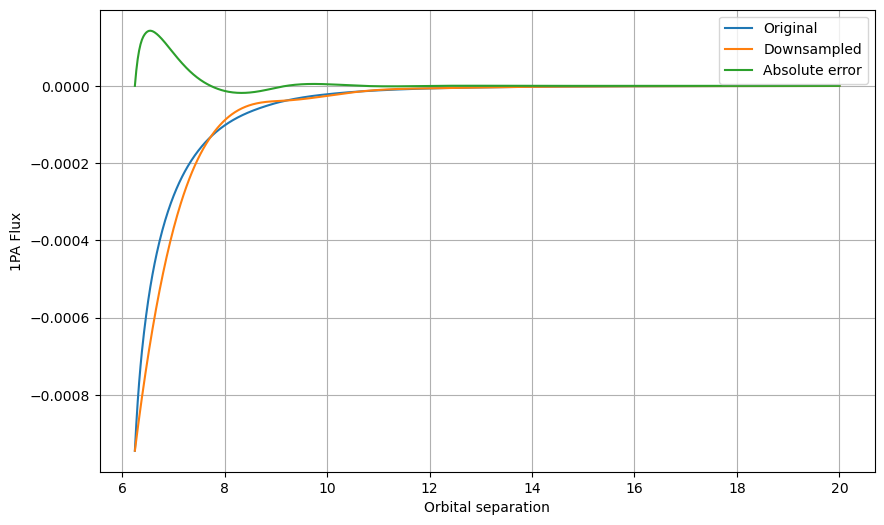

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(p_values, FluxInf1PA_values, label="Original")
plt.plot(p_values, FluxInf1PA_values_downsample, label="Downsampled")
plt.plot(p_values, FluxInf1PA_values-FluxInf1PA_values_downsample, label="Absolute error")
plt.xlabel("Orbital separation")
plt.ylabel("1PA Flux")
plt.grid()
plt.legend()
plt.show()


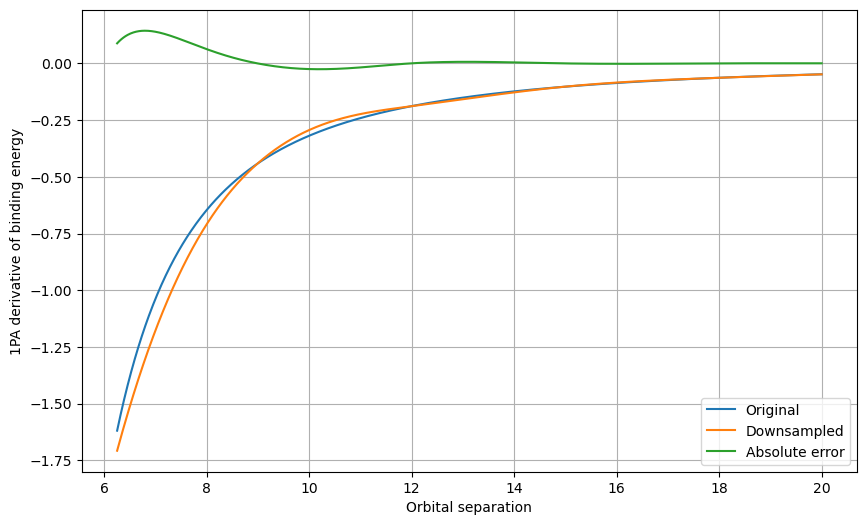

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(p_values, Energy1PA_values, label="Original")
plt.plot(p_values, Energy1PA_values_downsample, label="Downsampled")
plt.plot(p_values, Energy1PA_values-Energy1PA_values_downsample, label="Absolute error")
plt.xlabel("Orbital separation")
plt.ylabel("1PA derivative of binding energy")
plt.grid()
plt.legend()
plt.show()
